# Chapter 12: PCA and K-means on Simulated Data

This notebook follows the prompt:
- Simulate 3 classes (20 obs each), 50 features
- PCA and a scatter of the first two PCs
- K-means with K = 3, 2, 4 on the raw data
- K-means with K = 3 on the first two PC score vectors
- K-means with K = 3 after scaling each variable to unit variance (StandardScaler)
- Compare results using cross tabs and Adjusted Rand Index (ARI).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score

sns.set(style="whitegrid", context="notebook")
np.random.seed(42)

print('Libraries imported.')

Libraries imported.


## (a) Simulate data (3 classes x 20 obs, 50 features)

In [2]:
def simulate_data(n_per_class=20, p=50, sep=3.0, signal_dims=5, random_state=42):
    """
    Create a simple 3-class Gaussian simulation.
    - Class 0 center: all zeros
    - Class 1 center: +sep for the first `signal_dims` features
    - Class 2 center: -sep for the first `signal_dims` features
    Covariance is identity for all classes.
    """
    rng = np.random.default_rng(random_state)
    centers = np.zeros((3, p))
    centers[1, :signal_dims] = sep
    centers[2, :signal_dims] = -sep

    X_list, y_list = [], []
    for k in range(3):
        Xk = rng.normal(loc=centers[k], scale=1.0, size=(n_per_class, p))
        X_list.append(Xk)
        y_list.append(np.full(n_per_class, k))

    X = np.vstack(X_list)
    y = np.concatenate(y_list)
    return X, y, centers

# Generate one dataset (tweak `sep` or `signal_dims` if separation looks weak)
X, y, centers = simulate_data(sep=3.0, signal_dims=5, random_state=1)
df = pd.DataFrame(X, columns=[f'x{j+1}' for j in range(X.shape[1])])
df['class'] = y
df.head()

,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,...,x42,x43,x44,x45,x46,x47,x48,x49,x50,class
0,0.345584,0.821618,0.330437,-1.303157,0.905356,0.446375,-0.536953,0.581118,0.364572,0.294132,...,-0.683227,-0.072044,-0.944752,-0.098270,0.095483,0.035586,-0.506292,0.593748,0.891167,0
1,0.320848,-0.818230,0.731652,-0.501440,0.879161,-1.071787,0.914467,-0.020063,-1.248749,-0.313899,...,0.256486,-0.094828,-0.258848,1.055743,-2.250854,-0.138655,0.033000,-1.425349,0.332814,0
2,-0.651281,0.862445,-0.125592,0.669153,1.218844,0.382930,-0.875721,-1.514319,1.753384,-0.111292,...,1.456962,-0.053184,-0.053902,0.511536,-0.420857,-0.228535,0.425149,0.282416,-1.159297,0
3,0.833343,-0.590435,-1.056079,-0.900475,-0.390545,1.627300,-1.175536,0.160076,-2.137824,-0.001567,...,1.226271,0.962155,-2.711285,0.041703,-1.617467,1.109638,0.168106,0.548405,-1.065125,0
4,1.828430,2.020073,-1.064771,0.372815,-0.673302,-0.023570,-1.265637,1.867146,-0.969180,-0.296084,...,-0.178470,0.202624,-1.605748,1.812230,-0.602659,-1.539659,0.618842,-0.354804,0.324858,0


## (b) PCA and plot of first two principal component score vectors

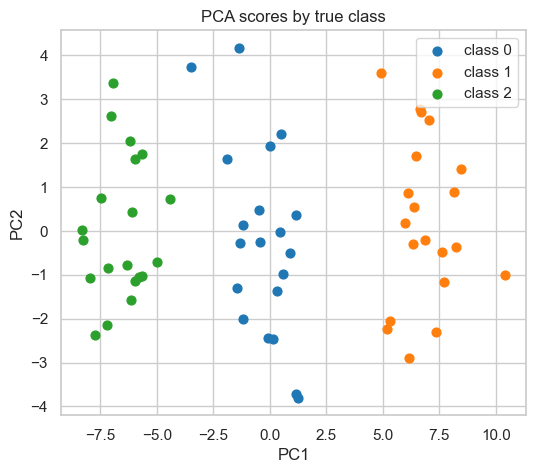

Explained variance ratios: [0.40526727 0.04437192]


In [3]:
pca = PCA(n_components=2, random_state=0)
Z = pca.fit_transform(X)

fig, ax = plt.subplots(1, 1, figsize=(6, 5))
palette = sns.color_palette('tab10', 3)
for k, color in zip(range(3), palette):
    ax.scatter(Z[y == k, 0], Z[y == k, 1], s=40, c=[color], label=f'class {k}')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title('PCA scores by true class')
ax.legend()
plt.show()

print('Explained variance ratios:', pca.explained_variance_ratio_)

## (c) Helper: K-means report with cross-tab and ARI

In [4]:
def cluster_report(X, y_true, k, random_state=0, n_init=10, title=None):
    km = KMeans(n_clusters=k, random_state=random_state, n_init=n_init)
    labels = km.fit_predict(X)
    ct = pd.crosstab(pd.Series(y_true, name='true'), pd.Series(labels, name='cluster'))
    ari = adjusted_rand_score(y_true, labels)
    if title:
        print(title)
    print(f'K={k} | inertia={km.inertia_:.1f} | ARI={ari:.3f}')
    display(ct)
    return labels, km

print('Helper ready.')

Helper ready.


## (d) K-means with K = 3 on the raw data

In [5]:
labels3_raw, km3_raw = cluster_report(X, y, k=3, random_state=1, n_init=10, title='Raw data')

Raw data
K=3 | inertia=2820.0 | ARI=0.950


cluster,0,1,2
true,,,
0,1,0,19
1,0,20,0
2,20,0,0


## (e) K-means with K = 2 and K = 4 on the raw data

In [6]:
_ = cluster_report(X, y, k=2, random_state=1, n_init=10, title='Raw data')
_ = cluster_report(X, y, k=4, random_state=1, n_init=10, title='Raw data')

Raw data
K=2 | inertia=3249.2 | ARI=0.563


cluster,0,1
true,,
0,0,20
1,20,0
2,0,20


Raw data
K=4 | inertia=2725.9 | ARI=0.847


cluster,0,1,2,3
true,,,,
0,1,0,19,0
1,0,5,0,15
2,20,0,0,0


## (f) K-means with K = 3 on the first two PC scores

PCA (2D scores)
K=3 | inertia=283.3 | ARI=0.950


cluster,0,1,2
true,,,
0,0,1,19
1,20,0,0
2,0,20,0


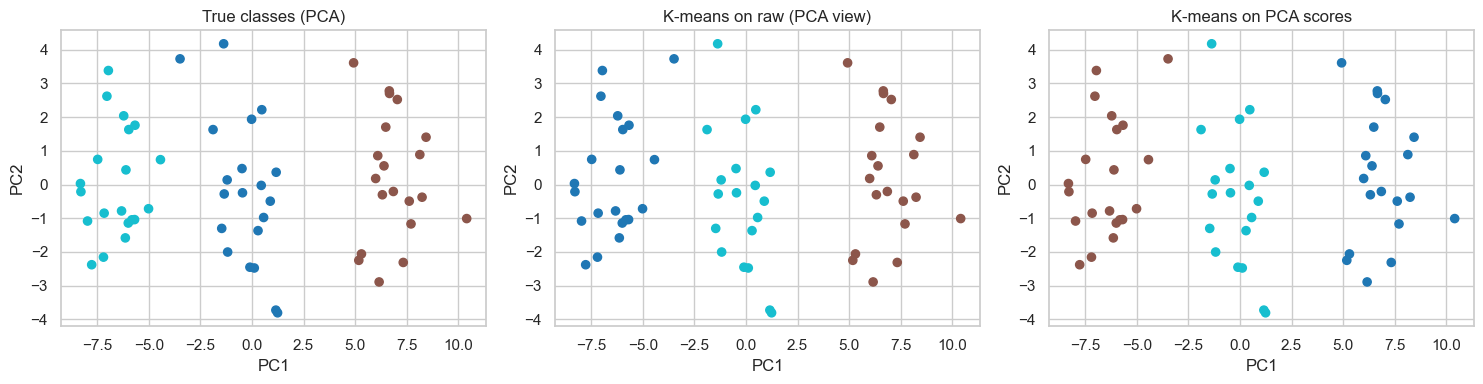

In [7]:
labels3_pca2, km3_pca2 = cluster_report(Z, y, k=3, random_state=1, n_init=10, title='PCA (2D scores)')

# Visual comparison in PCA space
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].scatter(Z[:, 0], Z[:, 1], c=y, cmap='tab10', s=35)
axes[0].set_title('True classes (PCA)')
axes[1].scatter(Z[:, 0], Z[:, 1], c=labels3_raw, cmap='tab10', s=35)
axes[1].set_title('K-means on raw (PCA view)')
axes[2].scatter(Z[:, 0], Z[:, 1], c=labels3_pca2, cmap='tab10', s=35)
axes[2].set_title('K-means on PCA scores')
for ax in axes:
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
plt.tight_layout()
plt.show()

## (g) Standardize features, then K-means with K = 3

In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
labels3_scaled, km3_scaled = cluster_report(X_scaled, y, k=3, random_state=1, n_init=10, title='Scaled data')

Scaled data
K=3 | inertia=2633.9 | ARI=0.465


cluster,0,1,2
true,,,
0,4,1,15
1,0,14,6
2,18,0,2


### Notes
- Cluster indices are arbitrary; use the cross-tab to compare, not raw label equality.
- ARI close to 1.0 indicates strong agreement with the true classes.
- In this simulation, separation is introduced in only a few dimensions (`signal_dims`).
  PCA captures this separation in the top components, so K-means on the two PC scores can perform well.
- Scaling affects K-means when variables have different variances; here all features were simulated with unit variance,
  so scaling mainly centers and rescales but does not change the relative importance across features.